In [ ]:
# connecting drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Unzipped successfully

🧠 Patient Path: /content/brats2021/BraTS2021_Training_Data/BraTS2021_01066
📂 Files: ['BraTS2021_01066_flair.nii.gz', 'BraTS2021_01066_t1.nii.gz', 'BraTS2021_01066_t1ce.nii.gz', 'BraTS2021_01066_seg.nii.gz', 'BraTS2021_01066_t2.nii.gz']

📌 Found files:
FLAIR: /content/brats2021/BraTS2021_Training_Data/BraTS2021_01066/BraTS2021_01066_flair.nii.gz
T1: /content/brats2021/BraTS2021_Training_Data/BraTS2021_01066/BraTS2021_01066_t1.nii.gz
T2: /content/brats2021/BraTS2021_Training_Data/BraTS2021_01066/BraTS2021_01066_t2.nii.gz
T1CE: /content/brats2021/BraTS2021_Training_Data/BraTS2021_01066/BraTS2021_01066_t1ce.nii.gz
SEG: /content/brats2021/BraTS2021_Training_Data/BraTS2021_01066/BraTS2021_01066_seg.nii.gz

📊 Shape check:
FLAIR shape: (240, 240, 155)
SEG shape: (240, 240, 155)
Unique labels: [0. 1. 2. 4.]


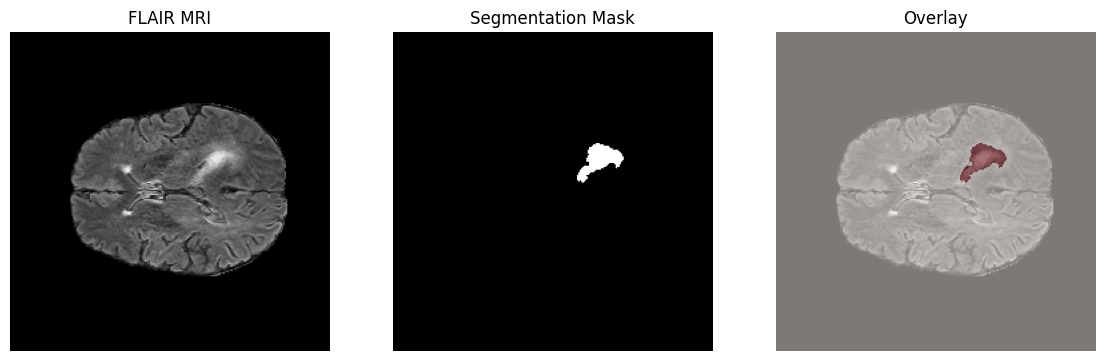


✅ Dataset OK: Tumor labels found


In [ ]:
# =========================
# 1. Mount Drive
# =========================
from google.colab import drive
drive.mount('/content/drive')

# =========================
# 2. Unzip dataset (cache)
# =========================
import zipfile, os

zip_path = "/content/drive/MyDrive/Mixture of Modality Expert Work/BraTS2021_Training_Data.zip"
extract_path = "/content/brats2021"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("✅ Unzipped successfully")

# =========================
# 3. Imports
# =========================
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt

# =========================
# 4. Get patient folder (FIXED STRUCTURE HANDLING)
# =========================
patients = sorted(os.listdir(extract_path))
patient_path = os.path.join(extract_path, patients[0])

# If nested structure exists, go one level deeper
sub_items = os.listdir(patient_path)
if os.path.isdir(os.path.join(patient_path, sub_items[0])):
    patient_path = os.path.join(patient_path, sub_items[0])

print("\n🧠 Patient Path:", patient_path)
files = os.listdir(patient_path)
print("📂 Files:", files)

# =========================
# 5. Safe file finder
# =========================
def find_file(keyword):
    for f in files:
        if keyword.lower() in f.lower():
            return os.path.join(patient_path, f)
    return None

flair_path = find_file("flair")
t1_path    = find_file("t1.nii")
t2_path    = find_file("t2")
t1ce_path  = find_file("t1ce")
seg_path   = find_file("seg")

print("\n📌 Found files:")
print("FLAIR:", flair_path)
print("T1:", t1_path)
print("T2:", t2_path)
print("T1CE:", t1ce_path)
print("SEG:", seg_path)

# =========================
# 6. Load images safely
# =========================
def load_nii(path):
    return nib.load(path).get_fdata()

flair = load_nii(flair_path)
seg   = load_nii(seg_path)

# =========================
# 7. Verification
# =========================
print("\n📊 Shape check:")
print("FLAIR shape:", flair.shape)
print("SEG shape:", seg.shape)
print("Unique labels:", np.unique(seg))

# =========================
# 8. Visualization (clean + correct)
# =========================
slice_idx = flair.shape[2] // 2

plt.figure(figsize=(14,5))

plt.subplot(1,3,1)
plt.imshow(flair[:,:,slice_idx], cmap='gray')
plt.title("FLAIR MRI")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(seg[:,:,slice_idx], cmap='gray')
plt.title("Segmentation Mask")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(flair[:,:,slice_idx], cmap='gray')
plt.imshow(seg[:,:,slice_idx], alpha=0.5, cmap='Reds')
plt.title("Overlay")
plt.axis('off')

plt.show()

# =========================
# 9. Final sanity check
# =========================
if seg is not None and np.max(seg) > 0:
    print("\n✅ Dataset OK: Tumor labels found")
else:
    print("\n❌ Warning: Empty or invalid segmentation mask")

🧠 Patient Path: /content/brats2021/BraTS2021_Training_Data/BraTS2021_01017

📂 Files:
BraTS2021_01017_t1ce.nii.gz
BraTS2021_01017_seg.nii.gz
BraTS2021_01017_flair.nii.gz
BraTS2021_01017_t2.nii.gz
BraTS2021_01017_t1.nii.gz

📌 Found Files:
FLAIR: /content/brats2021/BraTS2021_Training_Data/BraTS2021_01017/BraTS2021_01017_flair.nii.gz
T1: /content/brats2021/BraTS2021_Training_Data/BraTS2021_01017/BraTS2021_01017_t1.nii.gz
T2: /content/brats2021/BraTS2021_Training_Data/BraTS2021_01017/BraTS2021_01017_t2.nii.gz
T1CE: /content/brats2021/BraTS2021_Training_Data/BraTS2021_01017/BraTS2021_01017_t1ce.nii.gz
SEG: /content/brats2021/BraTS2021_Training_Data/BraTS2021_01017/BraTS2021_01017_seg.nii.gz

📊 Shape Check:
FLAIR: (240, 240, 155)
SEG: (240, 240, 155)
Labels: [0. 1. 2. 4.]


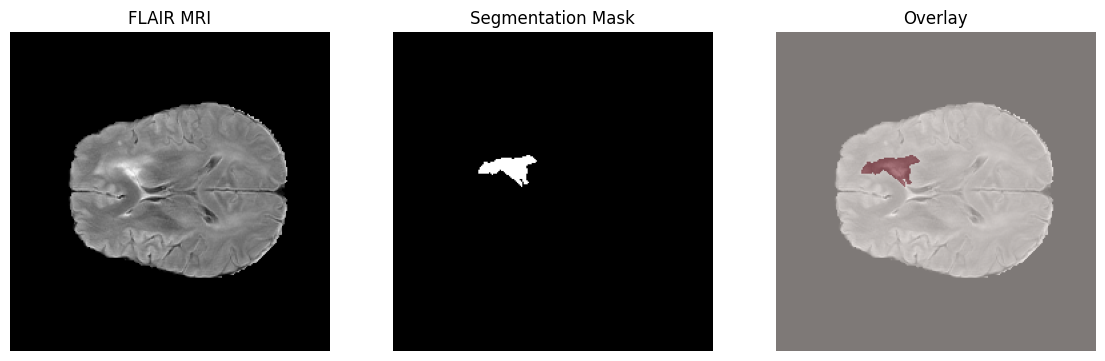


✅ VALID DATA: Lesions detected


In [ ]:
import os
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt

# =========================
# 1. SET YOUR PATIENT PATH HERE
# =========================
patient_path = "/content/brats2021/BraTS2021_Training_Data/BraTS2021_01017"

print("🧠 Patient Path:", patient_path)

files = os.listdir(patient_path)
print("\n📂 Files:")
for f in files:
    print(f)

# =========================
# 2. SAFE FILE FINDER
# =========================
def find_file(keyword):
    for f in files:
        if keyword.lower() in f.lower():
            return os.path.join(patient_path, f)
    return None

flair_path = find_file("flair")
t1_path    = find_file("t1.nii")
t2_path    = find_file("t2")
t1ce_path  = find_file("t1ce")
seg_path   = find_file("seg")

print("\n📌 Found Files:")
print("FLAIR:", flair_path)
print("T1:", t1_path)
print("T2:", t2_path)
print("T1CE:", t1ce_path)
print("SEG:", seg_path)

# =========================
# 3. LOAD NIFTI
# =========================
def load_nii(path):
    return nib.load(path).get_fdata()

flair = load_nii(flair_path)
seg   = load_nii(seg_path)

# =========================
# 4. BASIC CHECKS
# =========================
print("\n📊 Shape Check:")
print("FLAIR:", flair.shape)
print("SEG:", seg.shape)
print("Labels:", np.unique(seg))

# =========================
# 5. VISUALIZATION
# =========================
slice_idx = flair.shape[2] // 2

plt.figure(figsize=(14,5))

plt.subplot(1,3,1)
plt.imshow(flair[:,:,slice_idx], cmap='gray')
plt.title("FLAIR MRI")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(seg[:,:,slice_idx], cmap='gray')
plt.title("Segmentation Mask")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(flair[:,:,slice_idx], cmap='gray')
plt.imshow(seg[:,:,slice_idx], alpha=0.5, cmap='Reds')
plt.title("Overlay")
plt.axis('off')

plt.show()

# =========================
# 6. FINAL CHECK
# =========================
if seg is not None and np.max(seg) > 0:
    print("\n✅ VALID DATA: Lesions detected")
else:
    print("\n❌ WARNING: Empty or invalid segmentation")

🧠 Patient Path: /content/brats2021/BraTS2021_Training_Data/BraTS2021_01023

📂 Files:
BraTS2021_01023_seg.nii.gz
BraTS2021_01023_t1.nii.gz
BraTS2021_01023_t1ce.nii.gz
BraTS2021_01023_flair.nii.gz
BraTS2021_01023_t2.nii.gz

📌 Found Files:
FLAIR: /content/brats2021/BraTS2021_Training_Data/BraTS2021_01023/BraTS2021_01023_flair.nii.gz
T1: /content/brats2021/BraTS2021_Training_Data/BraTS2021_01023/BraTS2021_01023_t1.nii.gz
T2: /content/brats2021/BraTS2021_Training_Data/BraTS2021_01023/BraTS2021_01023_t2.nii.gz
T1CE: /content/brats2021/BraTS2021_Training_Data/BraTS2021_01023/BraTS2021_01023_t1ce.nii.gz
SEG: /content/brats2021/BraTS2021_Training_Data/BraTS2021_01023/BraTS2021_01023_seg.nii.gz

📊 Shape Check:
FLAIR: (240, 240, 155)
SEG: (240, 240, 155)
Labels: [0. 1. 2. 4.]


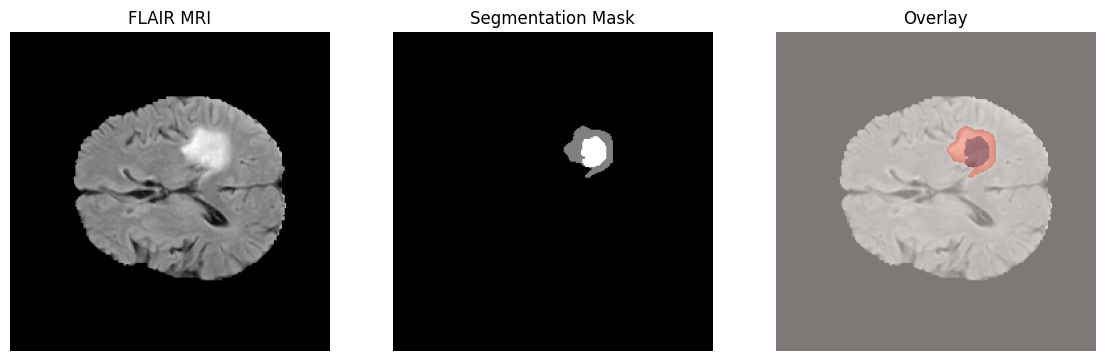


✅ VALID DATA: Lesions detected


In [ ]:
import os
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt

# =========================
# 1. SET YOUR PATIENT PATH HERE
# =========================
patient_path = "/content/brats2021/BraTS2021_Training_Data/BraTS2021_01023"

print("🧠 Patient Path:", patient_path)

files = os.listdir(patient_path)
print("\n📂 Files:")
for f in files:
    print(f)

# =========================
# 2. SAFE FILE FINDER
# =========================
def find_file(keyword):
    for f in files:
        if keyword.lower() in f.lower():
            return os.path.join(patient_path, f)
    return None

flair_path = find_file("flair")
t1_path    = find_file("t1.nii")
t2_path    = find_file("t2")
t1ce_path  = find_file("t1ce")
seg_path   = find_file("seg")

print("\n📌 Found Files:")
print("FLAIR:", flair_path)
print("T1:", t1_path)
print("T2:", t2_path)
print("T1CE:", t1ce_path)
print("SEG:", seg_path)

# =========================
# 3. LOAD NIFTI
# =========================
def load_nii(path):
    return nib.load(path).get_fdata()

flair = load_nii(flair_path)
seg   = load_nii(seg_path)

# =========================
# 4. BASIC CHECKS
# =========================
print("\n📊 Shape Check:")
print("FLAIR:", flair.shape)
print("SEG:", seg.shape)
print("Labels:", np.unique(seg))

# =========================
# 5. VISUALIZATION
# =========================
slice_idx = flair.shape[2] // 2

plt.figure(figsize=(14,5))

plt.subplot(1,3,1)
plt.imshow(flair[:,:,slice_idx], cmap='gray')
plt.title("FLAIR MRI")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(seg[:,:,slice_idx], cmap='gray')
plt.title("Segmentation Mask")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(flair[:,:,slice_idx], cmap='gray')
plt.imshow(seg[:,:,slice_idx], alpha=0.5, cmap='Reds')
plt.title("Overlay")
plt.axis('off')

plt.show()

# =========================
# 6. FINAL CHECK
# =========================
if seg is not None and np.max(seg) > 0:
    print("\n✅ VALID DATA: Lesions detected")
else:
    print("\n❌ WARNING: Empty or invalid segmentation")

🧠 Patient: /content/brats2021/BraTS2021_Training_Data/BraTS2021_01017

📂 Files:
BraTS2021_01017_t1ce.nii.gz
BraTS2021_01017_seg.nii.gz
BraTS2021_01017_flair.nii.gz
BraTS2021_01017_t2.nii.gz
BraTS2021_01017_t1.nii.gz

📌 Found Files:
FLAIR: /content/brats2021/BraTS2021_Training_Data/BraTS2021_01017/BraTS2021_01017_flair.nii.gz
T1: /content/brats2021/BraTS2021_Training_Data/BraTS2021_01017/BraTS2021_01017_t1.nii.gz
T1CE: /content/brats2021/BraTS2021_Training_Data/BraTS2021_01017/BraTS2021_01017_t1ce.nii.gz
T2: /content/brats2021/BraTS2021_Training_Data/BraTS2021_01017/BraTS2021_01017_t2.nii.gz
SEG: /content/brats2021/BraTS2021_Training_Data/BraTS2021_01017/BraTS2021_01017_seg.nii.gz

📊 Shape Check:
FLAIR: (240, 240, 155)
T1: (240, 240, 155)
T1CE: (240, 240, 155)
T2: (240, 240, 155)
SEG: (240, 240, 155)

🔢 Segmentation Labels: [0. 1. 2. 4.]


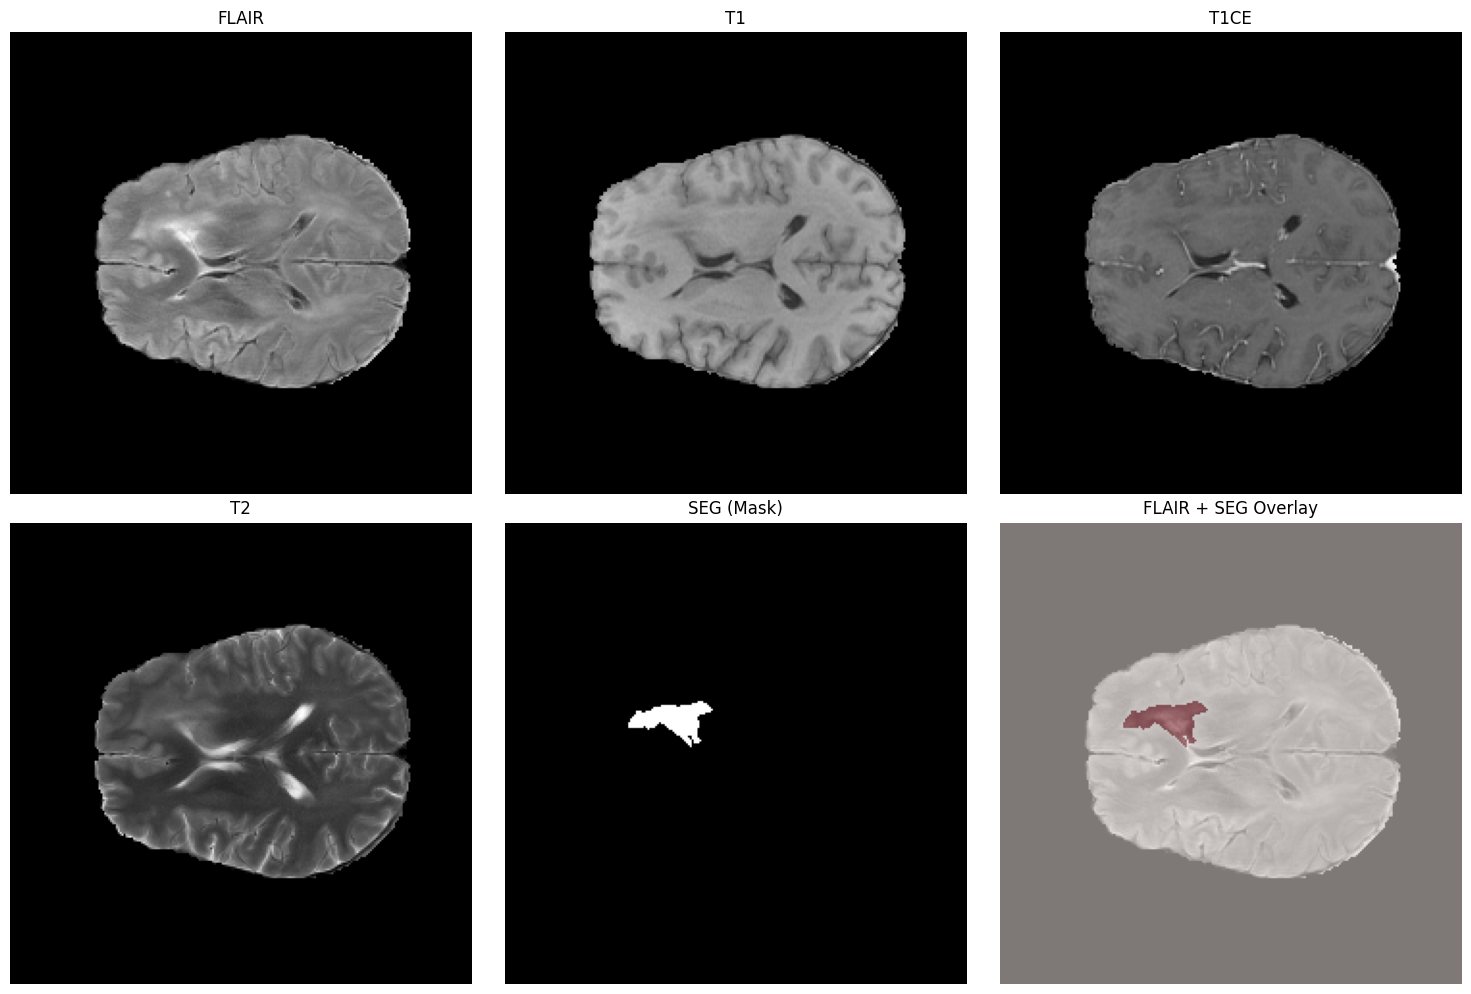


✅ DATASET VALID: All modalities + lesions found


In [ ]:
import os
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt

# =========================
# 1. SET PATIENT PATH
# =========================
patient_path = "/content/brats2021/BraTS2021_Training_Data/BraTS2021_01017"

print("🧠 Patient:", patient_path)

files = os.listdir(patient_path)
print("\n📂 Files:")
for f in files:
    print(f)

# =========================
# 2. SAFE FILE FINDER
# =========================
def find_file(keyword):
    for f in files:
        if keyword.lower() in f.lower():
            return os.path.join(patient_path, f)
    return None

flair_path = find_file("flair")
t1_path    = find_file("t1.nii")
t1ce_path  = find_file("t1ce")
t2_path    = find_file("t2")
seg_path   = find_file("seg")

print("\n📌 Found Files:")
print("FLAIR:", flair_path)
print("T1:", t1_path)
print("T1CE:", t1ce_path)
print("T2:", t2_path)
print("SEG:", seg_path)

# =========================
# 3. LOAD FUNCTION
# =========================
def load_nii(path):
    return nib.load(path).get_fdata()

flair = load_nii(flair_path)
t1    = load_nii(t1_path)
t1ce  = load_nii(t1ce_path)
t2    = load_nii(t2_path)
seg   = load_nii(seg_path)

# =========================
# 4. BASIC VERIFICATION
# =========================
print("\n📊 Shape Check:")
print("FLAIR:", flair.shape)
print("T1:", t1.shape)
print("T1CE:", t1ce.shape)
print("T2:", t2.shape)
print("SEG:", seg.shape)

print("\n🔢 Segmentation Labels:", np.unique(seg))

# =========================
# 5. VISUALIZATION (MULTI-MODAL)
# =========================
slice_idx = flair.shape[2] // 2

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

axes[0,0].imshow(flair[:,:,slice_idx], cmap='gray')
axes[0,0].set_title("FLAIR")
axes[0,0].axis('off')

axes[0,1].imshow(t1[:,:,slice_idx], cmap='gray')
axes[0,1].set_title("T1")
axes[0,1].axis('off')

axes[0,2].imshow(t1ce[:,:,slice_idx], cmap='gray')
axes[0,2].set_title("T1CE")
axes[0,2].axis('off')

axes[1,0].imshow(t2[:,:,slice_idx], cmap='gray')
axes[1,0].set_title("T2")
axes[1,0].axis('off')

axes[1,1].imshow(seg[:,:,slice_idx], cmap='gray')
axes[1,1].set_title("SEG (Mask)")
axes[1,1].axis('off')

# Overlay (FLAIR + mask)
axes[1,2].imshow(flair[:,:,slice_idx], cmap='gray')
axes[1,2].imshow(seg[:,:,slice_idx], alpha=0.5, cmap='Reds')
axes[1,2].set_title("FLAIR + SEG Overlay")
axes[1,2].axis('off')

plt.tight_layout()
plt.show()

# =========================
# 6. FINAL SANITY CHECK
# =========================
checks = [
    flair is not None,
    t1 is not None,
    t1ce is not None,
    t2 is not None,
    seg is not None,
    np.max(seg) > 0
]

if all(checks):
    print("\n✅ DATASET VALID: All modalities + lesions found")
else:
    print("\n❌ WARNING: Missing or corrupted modality detected")

🧠 Patient: /content/brats2021/BraTS2021_Training_Data/BraTS2021_01018

📂 Files:
BraTS2021_01018_flair.nii.gz
BraTS2021_01018_t2.nii.gz
BraTS2021_01018_t1ce.nii.gz
BraTS2021_01018_t1.nii.gz
BraTS2021_01018_seg.nii.gz

📌 Found Files:
FLAIR: /content/brats2021/BraTS2021_Training_Data/BraTS2021_01018/BraTS2021_01018_flair.nii.gz
T1: /content/brats2021/BraTS2021_Training_Data/BraTS2021_01018/BraTS2021_01018_t1.nii.gz
T1CE: /content/brats2021/BraTS2021_Training_Data/BraTS2021_01018/BraTS2021_01018_t1ce.nii.gz
T2: /content/brats2021/BraTS2021_Training_Data/BraTS2021_01018/BraTS2021_01018_t2.nii.gz
SEG: /content/brats2021/BraTS2021_Training_Data/BraTS2021_01018/BraTS2021_01018_seg.nii.gz

📊 Shape Check:
FLAIR: (240, 240, 155)
T1: (240, 240, 155)
T1CE: (240, 240, 155)
T2: (240, 240, 155)
SEG: (240, 240, 155)

🔢 Segmentation Labels: [0. 1. 2. 4.]


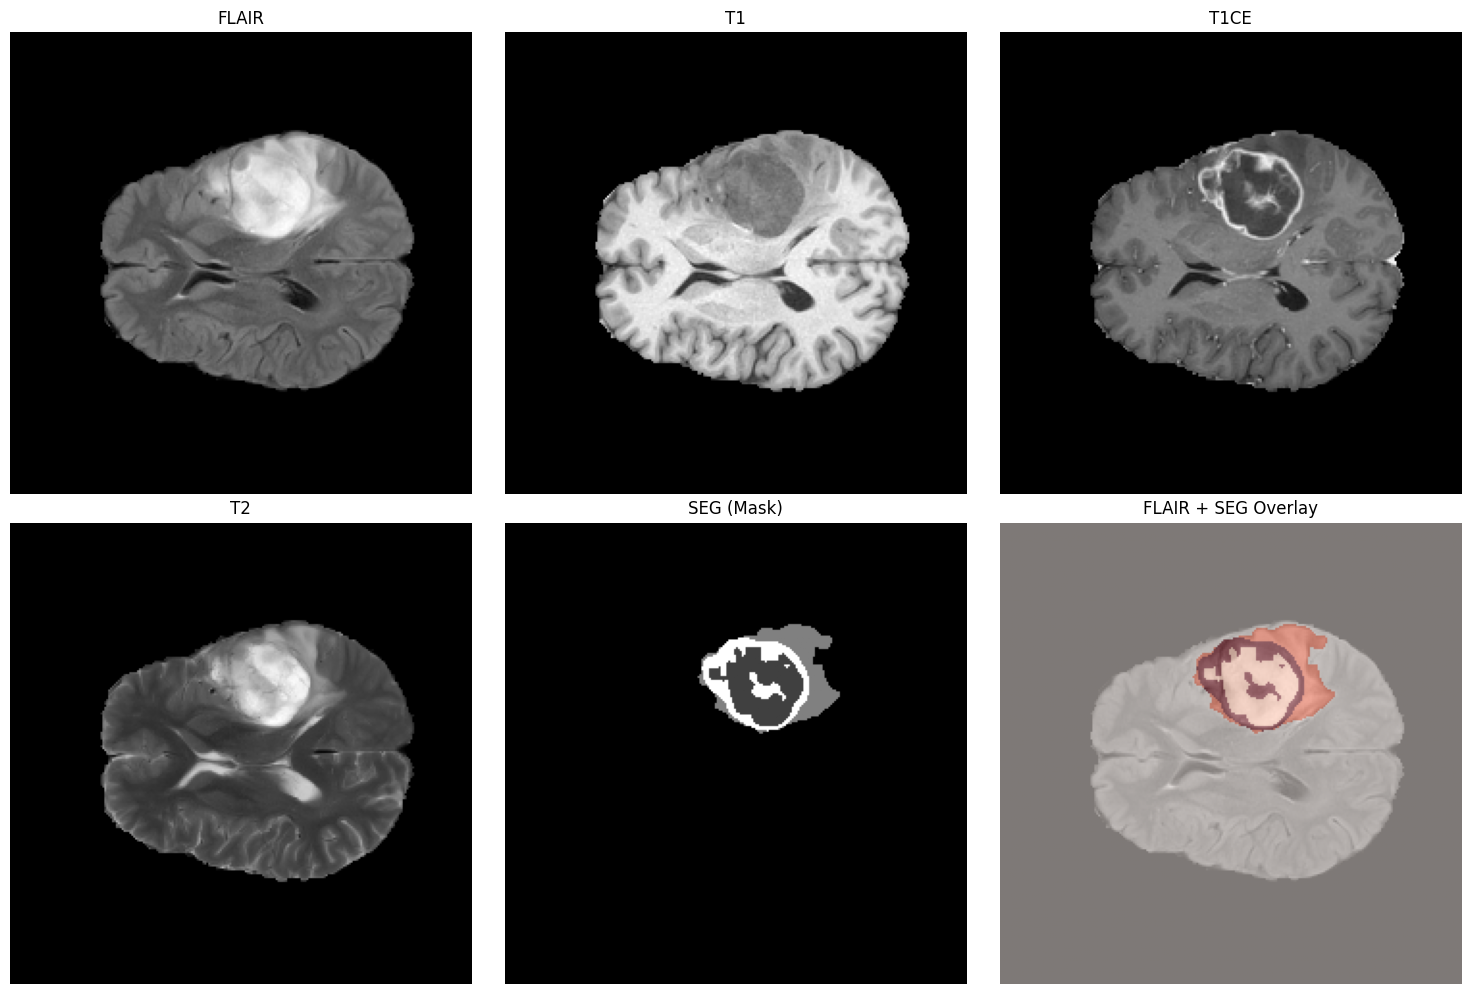


✅ DATASET VALID: All modalities + lesions found


In [ ]:
import os
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt

# =========================
# 1. SET PATIENT PATH
# =========================
patient_path = "/content/brats2021/BraTS2021_Training_Data/BraTS2021_01018"

print("🧠 Patient:", patient_path)

files = os.listdir(patient_path)
print("\n📂 Files:")
for f in files:
    print(f)

# =========================
# 2. SAFE FILE FINDER
# =========================
def find_file(keyword):
    for f in files:
        if keyword.lower() in f.lower():
            return os.path.join(patient_path, f)
    return None

flair_path = find_file("flair")
t1_path    = find_file("t1.nii")
t1ce_path  = find_file("t1ce")
t2_path    = find_file("t2")
seg_path   = find_file("seg")

print("\n📌 Found Files:")
print("FLAIR:", flair_path)
print("T1:", t1_path)
print("T1CE:", t1ce_path)
print("T2:", t2_path)
print("SEG:", seg_path)

# =========================
# 3. LOAD FUNCTION
# =========================
def load_nii(path):
    return nib.load(path).get_fdata()

flair = load_nii(flair_path)
t1    = load_nii(t1_path)
t1ce  = load_nii(t1ce_path)
t2    = load_nii(t2_path)
seg   = load_nii(seg_path)

# =========================
# 4. BASIC VERIFICATION
# =========================
print("\n📊 Shape Check:")
print("FLAIR:", flair.shape)
print("T1:", t1.shape)
print("T1CE:", t1ce.shape)
print("T2:", t2.shape)
print("SEG:", seg.shape)

print("\n🔢 Segmentation Labels:", np.unique(seg))

# =========================
# 5. VISUALIZATION (MULTI-MODAL)
# =========================
slice_idx = flair.shape[2] // 2

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

axes[0,0].imshow(flair[:,:,slice_idx], cmap='gray')
axes[0,0].set_title("FLAIR")
axes[0,0].axis('off')

axes[0,1].imshow(t1[:,:,slice_idx], cmap='gray')
axes[0,1].set_title("T1")
axes[0,1].axis('off')

axes[0,2].imshow(t1ce[:,:,slice_idx], cmap='gray')
axes[0,2].set_title("T1CE")
axes[0,2].axis('off')

axes[1,0].imshow(t2[:,:,slice_idx], cmap='gray')
axes[1,0].set_title("T2")
axes[1,0].axis('off')

axes[1,1].imshow(seg[:,:,slice_idx], cmap='gray')
axes[1,1].set_title("SEG (Mask)")
axes[1,1].axis('off')

# Overlay (FLAIR + mask)
axes[1,2].imshow(flair[:,:,slice_idx], cmap='gray')
axes[1,2].imshow(seg[:,:,slice_idx], alpha=0.5, cmap='Reds')
axes[1,2].set_title("FLAIR + SEG Overlay")
axes[1,2].axis('off')

plt.tight_layout()
plt.show()

# =========================
# 6. FINAL SANITY CHECK
# =========================
checks = [
    flair is not None,
    t1 is not None,
    t1ce is not None,
    t2 is not None,
    seg is not None,
    np.max(seg) > 0
]

if all(checks):
    print("\n✅ DATASET VALID: All modalities + lesions found")
else:
    print("\n❌ WARNING: Missing or corrupted modality detected")

🧠 Patient: /content/brats2021/BraTS2021_Training_Data/BraTS2021_01018


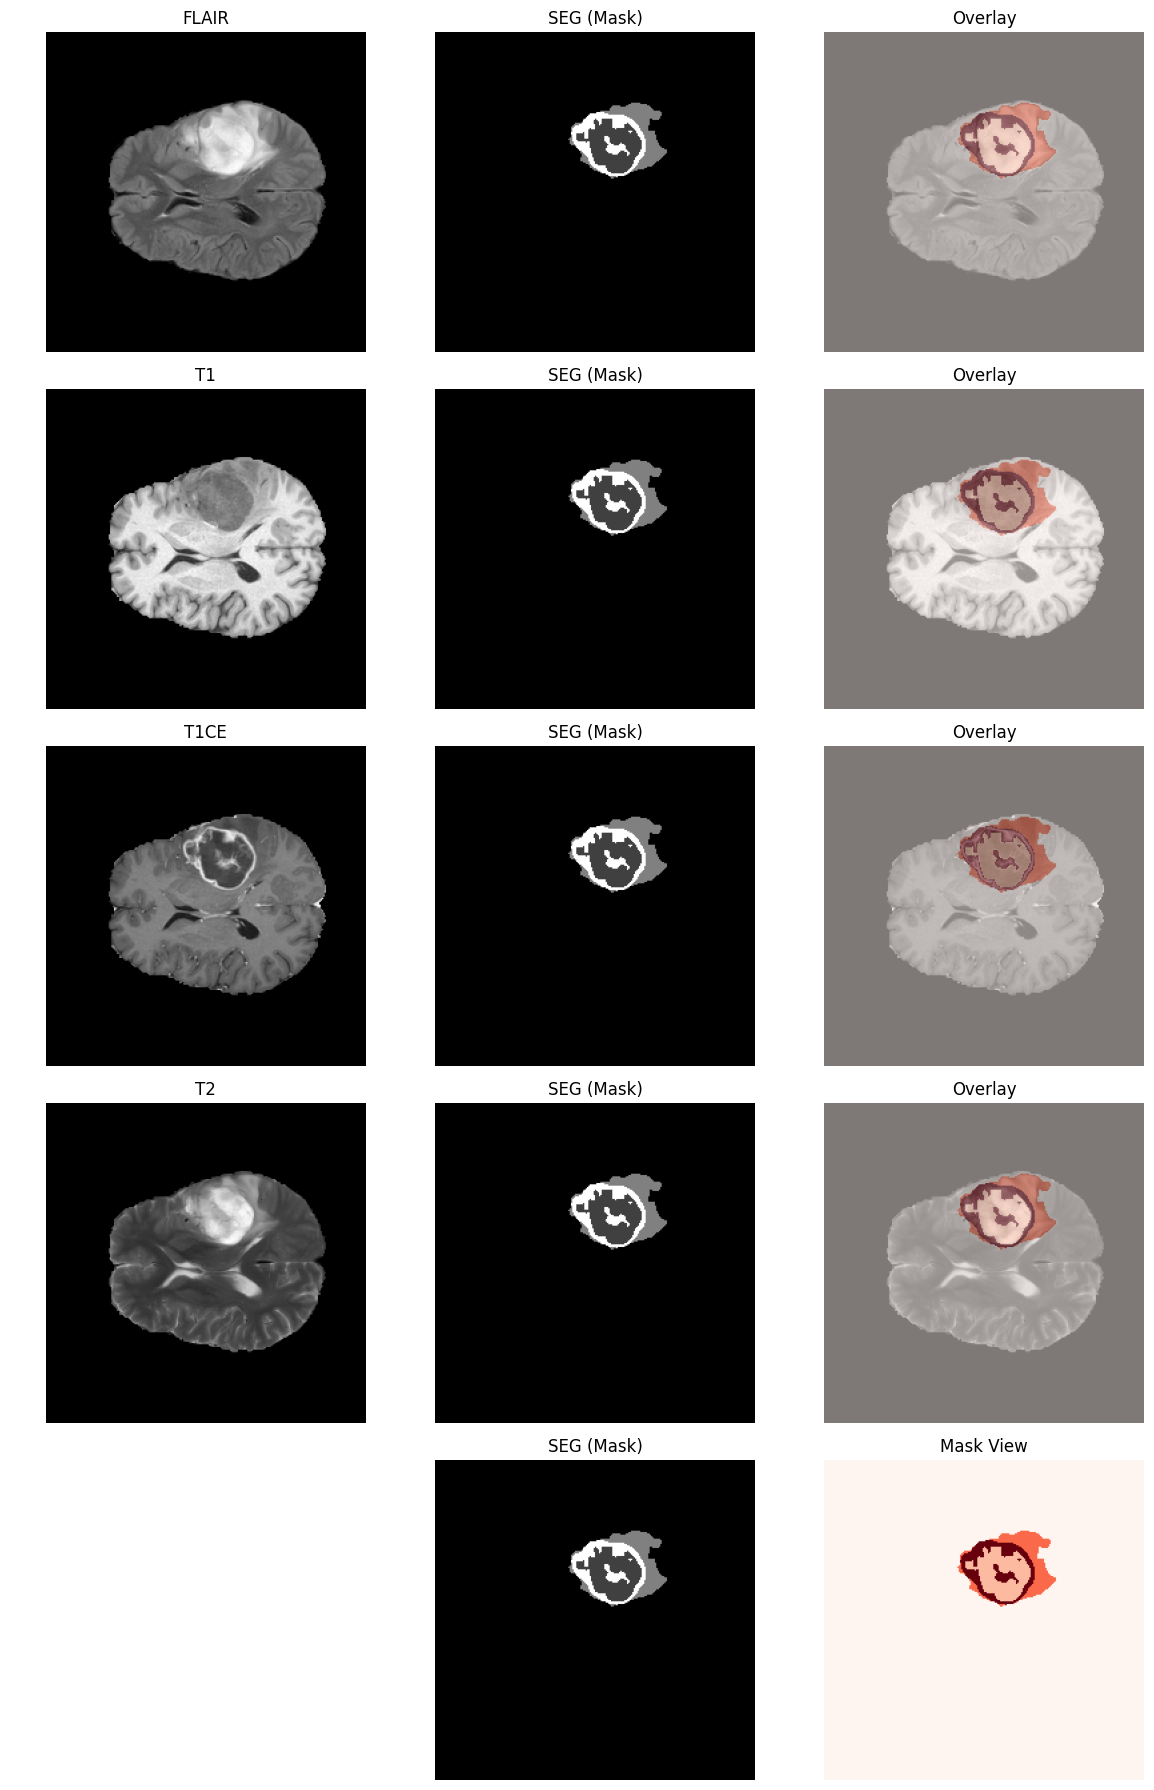


🔢 Segmentation Labels: [0. 1. 2. 4.]

✅ DATASET VALID: Lesions present


In [ ]:
import os
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt

# =========================
# 1. SET PATIENT PATH
# =========================
patient_path = "/content/brats2021/BraTS2021_Training_Data/BraTS2021_01018"

print("🧠 Patient:", patient_path)

files = os.listdir(patient_path)

# =========================
# 2. SAFE FILE FINDER
# =========================
def find_file(keyword):
    for f in files:
        if keyword.lower() in f.lower():
            return os.path.join(patient_path, f)
    return None

flair_path = find_file("flair")
t1_path    = find_file("t1.nii")
t1ce_path  = find_file("t1ce")
t2_path    = find_file("t2")
seg_path   = find_file("seg")

# =========================
# 3. LOAD FUNCTION
# =========================
def load_nii(path):
    return nib.load(path).get_fdata()

flair = load_nii(flair_path)
t1    = load_nii(t1_path)
t1ce  = load_nii(t1ce_path)
t2    = load_nii(t2_path)
seg   = load_nii(seg_path)

# =========================
# 4. SLICE SELECTION
# =========================
slice_idx = flair.shape[2] // 2

# =========================
# 5. MULTI-MODAL GRID (5 rows × 3 cols)
# Rows = modalities
# Cols = Modality | Mask | Overlay
# =========================
modalities = [
    ("FLAIR", flair),
    ("T1", t1),
    ("T1CE", t1ce),
    ("T2", t2),
    ("SEG_REF", flair)  # reference row for mask-only view (no modality needed)
]

fig, axes = plt.subplots(5, 3, figsize=(12, 18))

for i, (name, img) in enumerate(modalities):

    # 1st column: modality (or blank for SEG row)
    if name != "SEG_REF":
        axes[i, 0].imshow(img[:, :, slice_idx], cmap='gray')
        axes[i, 0].set_title(name)
    else:
        axes[i, 0].axis('off')

    axes[i, 0].axis('off')

    # 2nd column: SEG mask
    axes[i, 1].imshow(seg[:, :, slice_idx], cmap='gray')
    axes[i, 1].set_title("SEG (Mask)")
    axes[i, 1].axis('off')

    # 3rd column: Overlay
    if name != "SEG_REF":
        axes[i, 2].imshow(img[:, :, slice_idx], cmap='gray')
        axes[i, 2].imshow(seg[:, :, slice_idx], alpha=0.5, cmap='Reds')
        axes[i, 2].set_title("Overlay")
    else:
        axes[i, 2].imshow(seg[:, :, slice_idx], cmap='Reds')
        axes[i, 2].set_title("Mask View")

    axes[i, 2].axis('off')

plt.tight_layout()
plt.show()

# =========================
# 6. FINAL CHECK
# =========================
print("\n🔢 Segmentation Labels:", np.unique(seg))

if np.max(seg) > 0:
    print("\n✅ DATASET VALID: Lesions present")
else:
    print("\n❌ WARNING: Empty segmentation")

🧠 Patient: /content/brats2021/BraTS2021_Training_Data/BraTS2021_01019


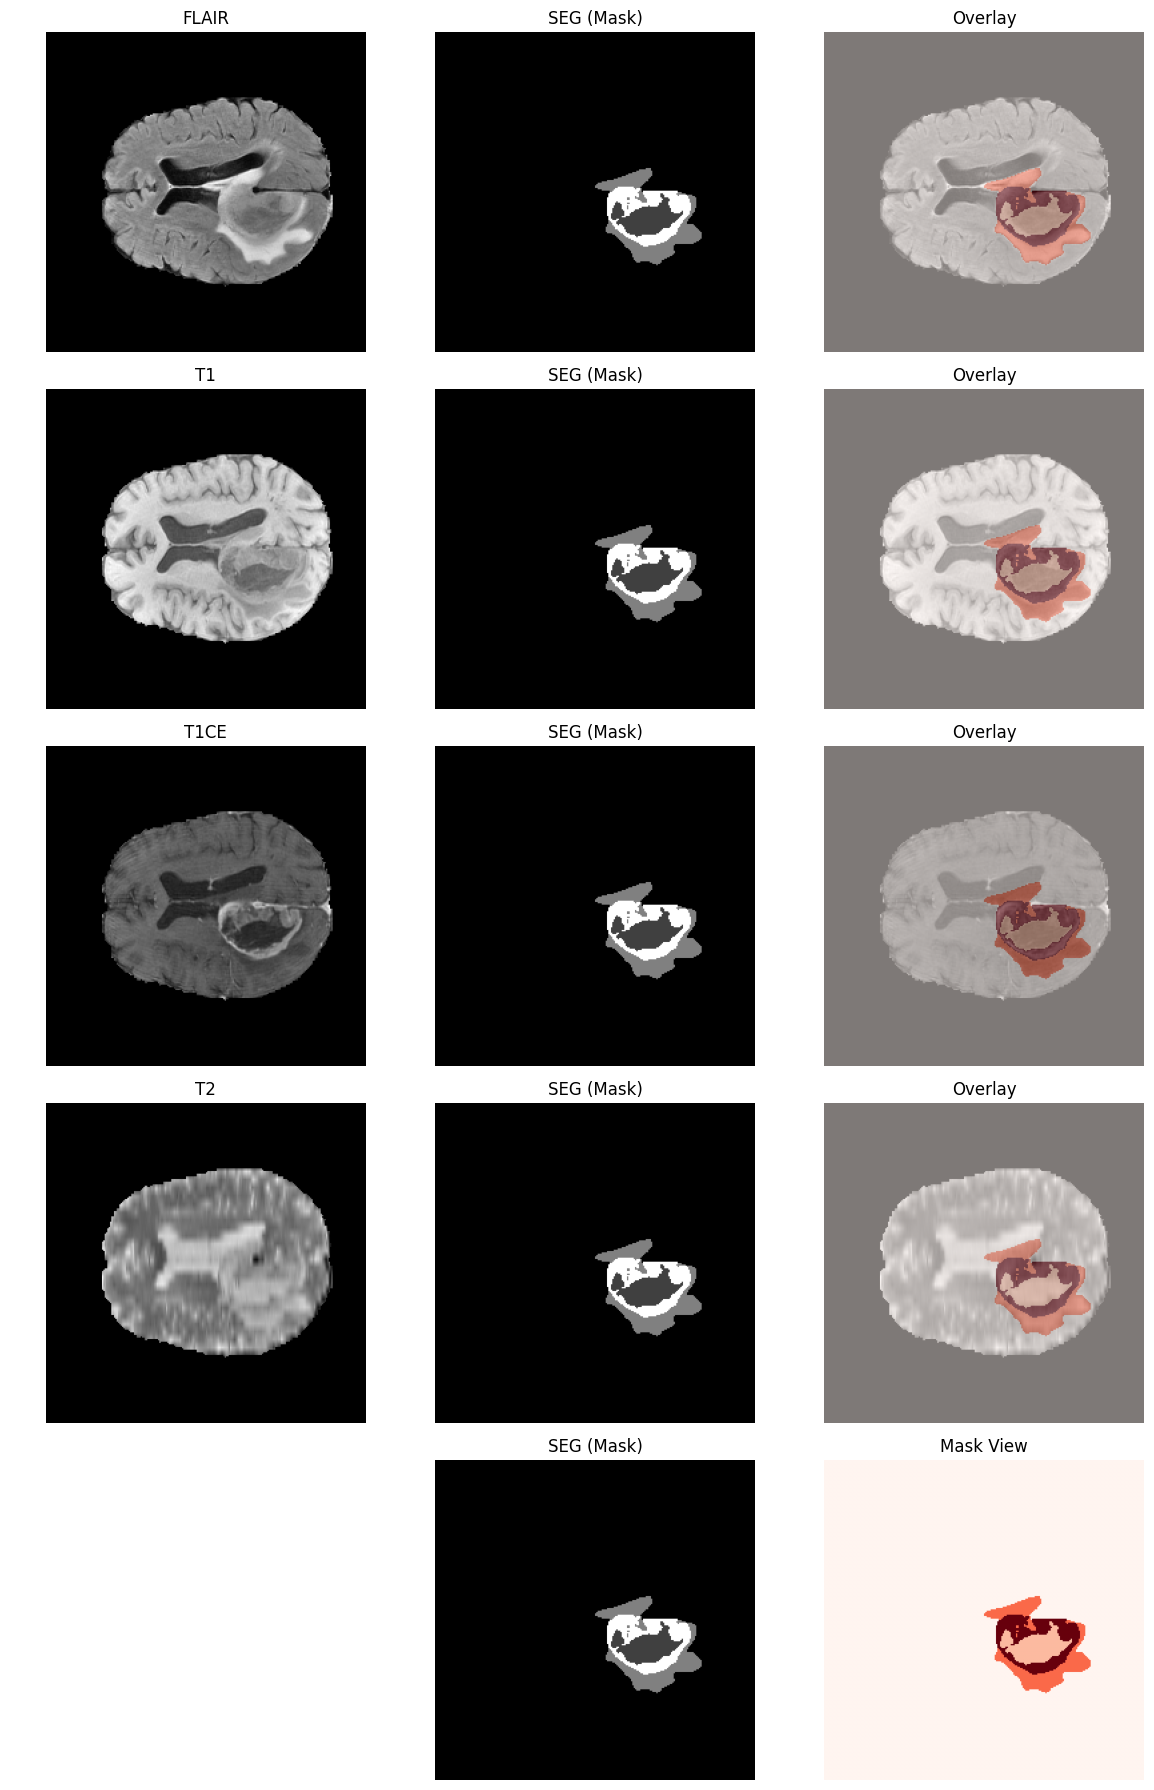


🔢 Segmentation Labels: [0. 1. 2. 4.]

✅ DATASET VALID: Lesions present


In [ ]:
import os
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt

# =========================
# 1. SET PATIENT PATH
# =========================
patient_path = "/content/brats2021/BraTS2021_Training_Data/BraTS2021_01019"

print("🧠 Patient:", patient_path)

files = os.listdir(patient_path)

# =========================
# 2. SAFE FILE FINDER
# =========================
def find_file(keyword):
    for f in files:
        if keyword.lower() in f.lower():
            return os.path.join(patient_path, f)
    return None

flair_path = find_file("flair")
t1_path    = find_file("t1.nii")
t1ce_path  = find_file("t1ce")
t2_path    = find_file("t2")
seg_path   = find_file("seg")

# =========================
# 3. LOAD FUNCTION
# =========================
def load_nii(path):
    return nib.load(path).get_fdata()

flair = load_nii(flair_path)
t1    = load_nii(t1_path)
t1ce  = load_nii(t1ce_path)
t2    = load_nii(t2_path)
seg   = load_nii(seg_path)

# =========================
# 4. SLICE SELECTION
# =========================
slice_idx = flair.shape[2] // 2

# =========================
# 5. MULTI-MODAL GRID (5 rows × 3 cols)
# Rows = modalities
# Cols = Modality | Mask | Overlay
# =========================
modalities = [
    ("FLAIR", flair),
    ("T1", t1),
    ("T1CE", t1ce),
    ("T2", t2),
    ("SEG_REF", flair)  # reference row for mask-only view (no modality needed)
]

fig, axes = plt.subplots(5, 3, figsize=(12, 18))

for i, (name, img) in enumerate(modalities):

    # 1st column: modality (or blank for SEG row)
    if name != "SEG_REF":
        axes[i, 0].imshow(img[:, :, slice_idx], cmap='gray')
        axes[i, 0].set_title(name)
    else:
        axes[i, 0].axis('off')

    axes[i, 0].axis('off')

    # 2nd column: SEG mask
    axes[i, 1].imshow(seg[:, :, slice_idx], cmap='gray')
    axes[i, 1].set_title("SEG (Mask)")
    axes[i, 1].axis('off')

    # 3rd column: Overlay
    if name != "SEG_REF":
        axes[i, 2].imshow(img[:, :, slice_idx], cmap='gray')
        axes[i, 2].imshow(seg[:, :, slice_idx], alpha=0.5, cmap='Reds')
        axes[i, 2].set_title("Overlay")
    else:
        axes[i, 2].imshow(seg[:, :, slice_idx], cmap='Reds')
        axes[i, 2].set_title("Mask View")

    axes[i, 2].axis('off')

plt.tight_layout()
plt.show()

# =========================
# 6. FINAL CHECK
# =========================
print("\n🔢 Segmentation Labels:", np.unique(seg))

if np.max(seg) > 0:
    print("\n✅ DATASET VALID: Lesions present")
else:
    print("\n❌ WARNING: Empty segmentation")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Drive mounted
📦 Extracting dataset...
✅ Extraction completed at: /content/brats2021
🧠 Patient: /content/brats2021/BraTS2021_Training_Data/BraTS2021_01019


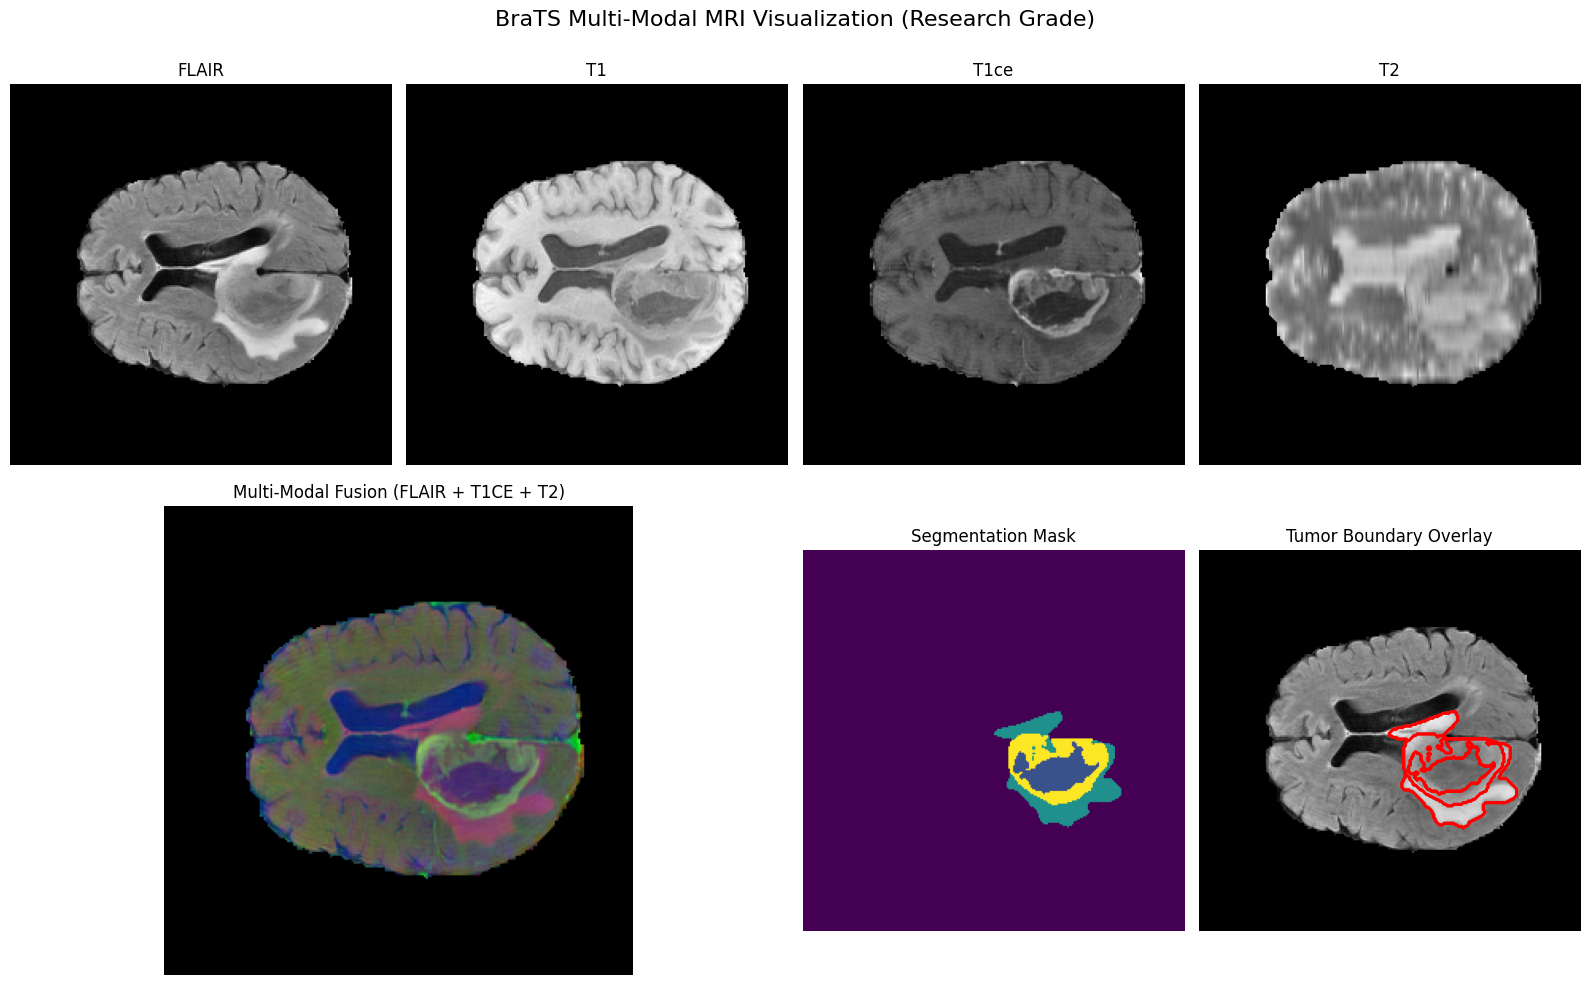

📊 Unique labels: [0. 1. 2. 4.]
✅ Lesion present in slice


In [2]:
import os
import zipfile
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import gridspec

# =========================
# 0. DRIVE MOUNT (OPTIONAL)
# =========================
USE_DRIVE = True

if USE_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
    print("✅ Drive mounted")

# =========================
# 1. ZIP PATHS
# =========================
zip_path = "/content/drive/MyDrive/Mixture of Modality Expert Work/BraTS2021_Training_Data.zip"
extract_path = "/content/brats2021"

# =========================
# 2. SAFE UNZIP (IDEMPOTENT)
# =========================
if os.path.exists(extract_path) and len(os.listdir(extract_path)) > 0:
    print("✅ Dataset already extracted. Skipping unzip.")
else:
    print("📦 Extracting dataset...")

    os.makedirs(extract_path, exist_ok=True)

    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)

    print("✅ Extraction completed at:", extract_path)

# =========================
# 3. SELECT PATIENT
# =========================
patient_path = os.path.join(
    extract_path,
    "BraTS2021_Training_Data",
    "BraTS2021_01019"
)

print("🧠 Patient:", patient_path)

files = os.listdir(patient_path)

# =========================
# 4. SAFE FILE FINDER
# =========================
def find_file(keyword):
    for f in files:
        if keyword.lower() in f.lower():
            return os.path.join(patient_path, f)
    return None

# =========================
# 5. LOAD DATA
# =========================
flair = nib.load(find_file("flair")).get_fdata()
t1    = nib.load(find_file("t1")).get_fdata()
t1ce  = nib.load(find_file("t1ce")).get_fdata()
t2    = nib.load(find_file("t2")).get_fdata()
seg   = nib.load(find_file("seg")).get_fdata()

# =========================
# 6. NORMALIZATION
# =========================
def normalize(img):
    img = img.astype(np.float32)
    return (img - np.mean(img)) / (np.std(img) + 1e-8)

flair, t1, t1ce, t2 = map(normalize, [flair, t1, t1ce, t2])

# =========================
# 7. SLICE SELECTION
# =========================
z = flair.shape[2] // 2

# =========================
# 8. PAPER-STYLE VISUALIZATION
# =========================
fig = plt.figure(figsize=(16, 10))
gs = gridspec.GridSpec(2, 4)

modalities = [
    ("FLAIR", flair),
    ("T1", t1),
    ("T1ce", t1ce),
    ("T2", t2)
]

# Row 1: Modalities
for i, (name, img) in enumerate(modalities):
    ax = fig.add_subplot(gs[0, i])
    ax.imshow(img[:, :, z], cmap="gray")
    ax.set_title(name)
    ax.axis("off")

# =========================
# 9. FUSION + SEG + OVERLAY
# =========================
fusion = np.stack([
    flair[:, :, z],
    t1ce[:, :, z],
    t2[:, :, z]
], axis=-1)

fusion = (fusion - fusion.min()) / (fusion.max() - fusion.min())

ax1 = fig.add_subplot(gs[1, 0:2])
ax1.imshow(fusion)
ax1.set_title("Multi-Modal Fusion (FLAIR + T1CE + T2)")
ax1.axis("off")

ax2 = fig.add_subplot(gs[1, 2])
ax2.imshow(seg[:, :, z], cmap="viridis")
ax2.set_title("Segmentation Mask")
ax2.axis("off")

ax3 = fig.add_subplot(gs[1, 3])
ax3.imshow(flair[:, :, z], cmap="gray")
ax3.contour(seg[:, :, z], colors="red", linewidths=1.5)
ax3.set_title("Tumor Boundary Overlay")
ax3.axis("off")

plt.suptitle("BraTS Multi-Modal MRI Visualization (Research Grade)", fontsize=16)
plt.tight_layout()
plt.show()

# =========================
# 10. CHECK
# =========================
print("📊 Unique labels:", np.unique(seg))

if np.max(seg) > 0:
    print("✅ Lesion present in slice")
else:
    print("❌ No lesion detected")

In [3]:
import os
import nibabel as nib
import numpy as np
import pandas as pd

# =========================
# PATH SETUP
# =========================
dataset_path = "/content/brats2021/BraTS2021_Training_Data"
patients = sorted(os.listdir(dataset_path))

# =========================
# MODALITIES
# =========================
modalities = ["flair", "t1", "t1ce", "t2", "seg"]

# =========================
# DATA STORAGE
# =========================
records = []

# =========================
# LOOP THROUGH PATIENTS
# =========================
for p in patients:

    p_path = os.path.join(dataset_path, p)

    if not os.path.isdir(p_path):
        continue

    file_list = os.listdir(p_path)

    def find(mod):
        for f in file_list:
            if mod in f.lower():
                return os.path.join(p_path, f)
        return None

    try:
        flair_path = find("flair")
        t1_path    = find("t1.nii")
        t1ce_path  = find("t1ce")
        t2_path    = find("t2")
        seg_path   = find("seg")

        # check missing modalities
        missing = [m for m, f in zip(modalities,
                    [flair_path, t1_path, t1ce_path, t2_path, seg_path]) if f is None]

        # skip broken samples safely
        if flair_path is None or seg_path is None:
            continue

        flair = nib.load(flair_path).get_fdata()
        seg   = nib.load(seg_path).get_fdata()

        tumor_present = np.max(seg) > 0
        unique_labels = np.unique(seg)

        records.append({
            "Patient_ID": p,
            "Missing_Modalities": missing,
            "Shape": flair.shape,
            "Tumor_Present": tumor_present,
            "Unique_Labels": unique_labels.tolist(),
            "Has_All_Modalities": len(missing) == 0
        })

    except Exception as e:
        records.append({
            "Patient_ID": p,
            "Missing_Modalities": "ERROR",
            "Shape": None,
            "Tumor_Present": None,
            "Unique_Labels": None,
            "Has_All_Modalities": False
        })

# =========================
# CREATE DATAFRAME
# =========================
df = pd.DataFrame(records)

# =========================
# SUMMARY
# =========================
print("📊 Dataset Summary")
print(df.head())

print("\n📈 Statistics:")
print("Total Patients:", len(df))
print("Complete Cases:", df["Has_All_Modalities"].sum())
print("Tumor Positive:", df["Tumor_Present"].sum())

📊 Dataset Summary
        Patient_ID Missing_Modalities            Shape  Tumor_Present  \
0  BraTS2021_01017                 []  (240, 240, 155)           True   
1  BraTS2021_01018                 []  (240, 240, 155)           True   
2  BraTS2021_01019                 []  (240, 240, 155)           True   
3  BraTS2021_01020                 []  (240, 240, 155)           True   
4  BraTS2021_01021                 []  (240, 240, 155)           True   

          Unique_Labels  Has_All_Modalities  
0  [0.0, 1.0, 2.0, 4.0]                True  
1  [0.0, 1.0, 2.0, 4.0]                True  
2  [0.0, 1.0, 2.0, 4.0]                True  
3  [0.0, 1.0, 2.0, 4.0]                True  
4  [0.0, 1.0, 2.0, 4.0]                True  

📈 Statistics:
Total Patients: 50
Complete Cases: 50
Tumor Positive: 50


In [5]:
import os
import nibabel as nib
import numpy as np
import pandas as pd

# =========================
# PATH (ONE PATIENT)
# =========================
patient_path = "/content/brats2021/BraTS2021_Training_Data/BraTS2021_01026"

files = os.listdir(patient_path)

# =========================
# FIND FILE FUNCTION
# =========================
def find(mod):
    for f in files:
        if mod in f.lower():
            return os.path.join(patient_path, f)
    return None

# =========================
# LOAD FILES
# =========================
flair_path = find("flair")
t1_path    = find("t1.nii")
t1ce_path  = find("t1ce")
t2_path    = find("t2")
seg_path   = find("seg")

missing = []

if flair_path is None: missing.append("flair")
if t1_path is None: missing.append("t1")
if t1ce_path is None: missing.append("t1ce")
if t2_path is None: missing.append("t2")
if seg_path is None: missing.append("seg")

# =========================
# LOAD DATA
# =========================
flair = nib.load(flair_path).get_fdata()
seg   = nib.load(seg_path).get_fdata()

# =========================
# METRICS
# =========================
record = {
    "Patient_ID": "BraTS2021_01026",
    "Missing_Modalities": missing,
    "Shape": flair.shape,
    "Tumor_Present": np.max(seg) > 0,
    "Unique_Labels": np.unique(seg).tolist(),
    "Has_All_Modalities": len(missing) == 0
}

df = pd.DataFrame([record])

print(df)

        Patient_ID Missing_Modalities            Shape  Tumor_Present  \
0  BraTS2021_01026                 []  (240, 240, 155)           True   

          Unique_Labels  Has_All_Modalities  
0  [0.0, 1.0, 2.0, 4.0]                True  


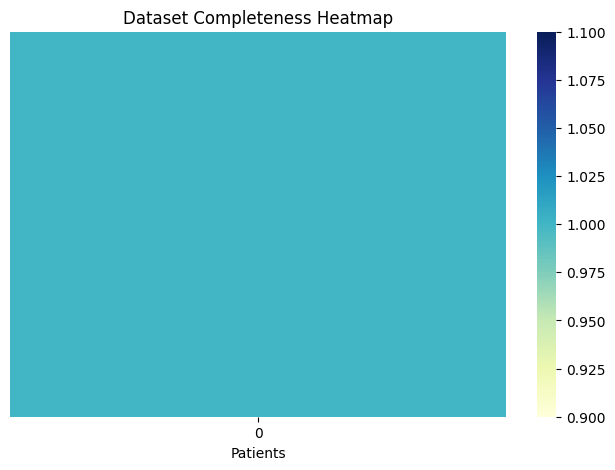

In [6]:
import seaborn as sns

# convert boolean completeness to numeric
df["Has_All_Modalities"] = df["Has_All_Modalities"].astype(int)

plt.figure(figsize=(8,5))
sns.heatmap(df[["Has_All_Modalities"]].T, cmap="YlGnBu", cbar=True)

plt.title("Dataset Completeness Heatmap")
plt.yticks([])
plt.xlabel("Patients")
plt.show()

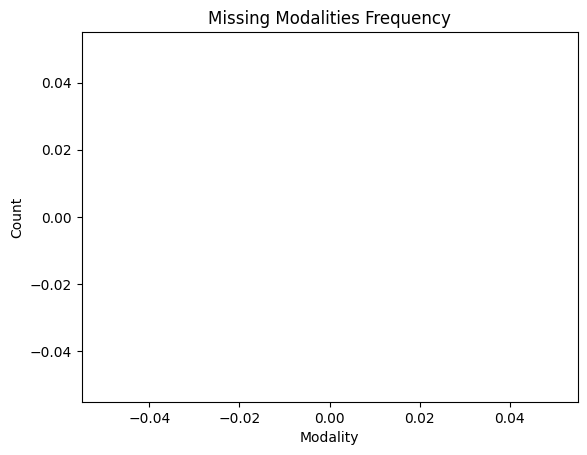

In [7]:
from collections import Counter

all_missing = sum(df["Missing_Modalities"], [])
missing_counts = Counter(all_missing)

plt.bar(missing_counts.keys(), missing_counts.values())

plt.title("Missing Modalities Frequency")
plt.xlabel("Modality")
plt.ylabel("Count")
plt.show()

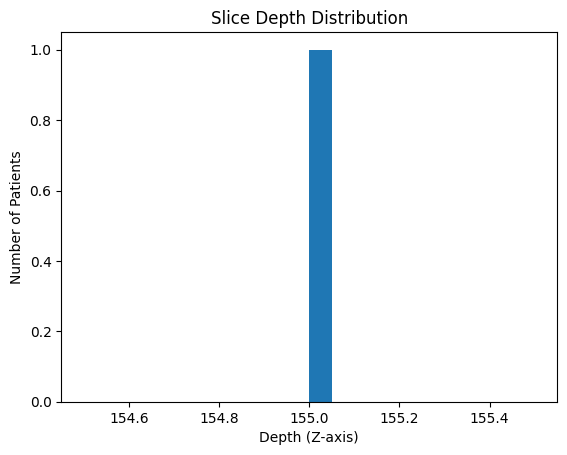

In [8]:
shapes = df["Shape"].dropna()

depths = [s[2] for s in shapes]

plt.hist(depths, bins=20)

plt.title("Slice Depth Distribution")
plt.xlabel("Depth (Z-axis)")
plt.ylabel("Number of Patients")
plt.show()

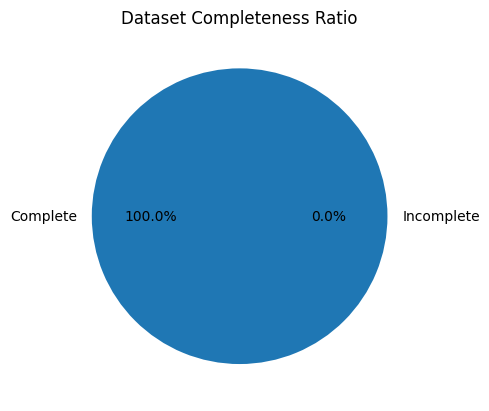

In [9]:
labels = ["Complete", "Incomplete"]
sizes = [
    df["Has_All_Modalities"].sum(),
    len(df) - df["Has_All_Modalities"].sum()
]

plt.pie(sizes, labels=labels, autopct="%1.1f%%")
plt.title("Dataset Completeness Ratio")
plt.show()

/usr/local/lib/python3.12/dist-packages/seaborn/matrix.py:202: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
/usr/local/lib/python3.12/dist-packages/seaborn/matrix.py:207: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)


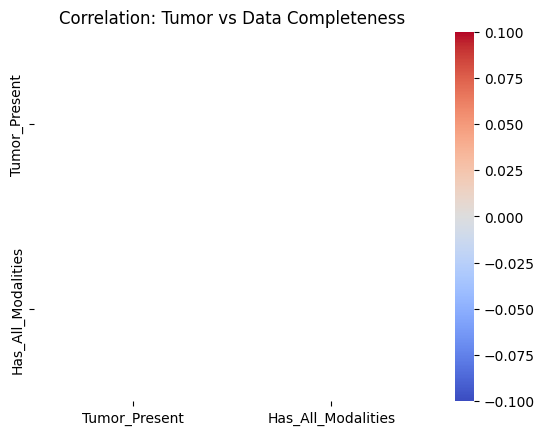

In [10]:
import seaborn as sns

df["Tumor_Present"] = df["Tumor_Present"].astype(int)

corr = df[["Tumor_Present", "Has_All_Modalities"]].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Correlation: Tumor vs Data Completeness")
plt.show()